# Obesity Level Classification


In [7]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import pathlib
import warnings
warnings.filterwarnings("ignore")

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, classification_report
)

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

import pickle

# Visualization & display settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

# Reproducibility
RANDOM_STATE = 42

print('Libraries loaded successfully')

Libraries loaded successfully


In [8]:
# Load the Obesity Levels dataset

df = pd.read_csv("obesity_levels.csv")

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

df.head()


Dataset loaded successfully!
Dataset shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [9]:
# Dataset overview
print("Dataset info:\n")
df.info()

# Dataset data types
print("\nDataset dtypes:\n")
print(df.dtypes)

# Missing values check
print("\nMissing values in dataset:\n")
print(df.isnull().sum())

# Statistical summary of numerical features
print("\nDataset describe():\n")
df.describe()

# Target column information
print("\nTarget column information:")
print(" - Name: NObeyesdad")
print(" - Meaning: Obesity level category (multi-class classification)")
print(" - Classes:", df['NObeyesdad'].unique())


Dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                

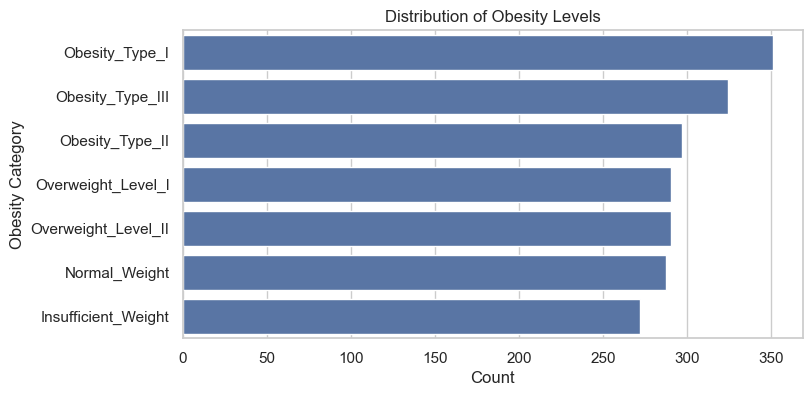

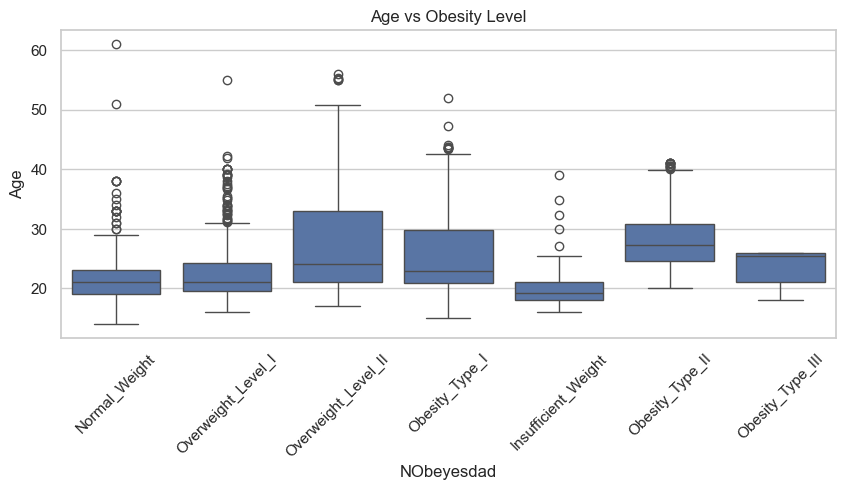

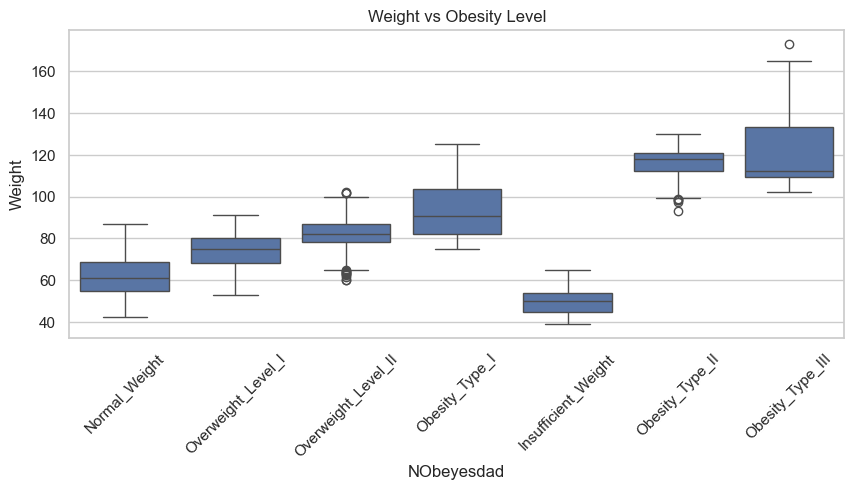

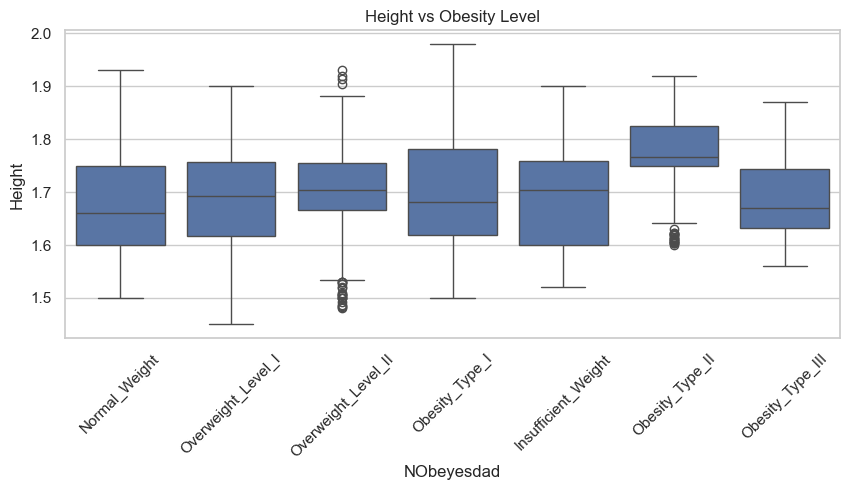

In [10]:

# EDA: Target Distribution

plt.figure(figsize=(8,4))
sns.countplot(
    y=df['NObeyesdad'],
    order=df['NObeyesdad'].value_counts().index
)
plt.title("Distribution of Obesity Levels")
plt.xlabel("Count")
plt.ylabel("Obesity Category")
plt.show()

# EDA: Numerical Features vs Target

plt.figure(figsize=(10,4))
sns.boxplot(x='NObeyesdad', y='Age', data=df)
plt.title("Age vs Obesity Level")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(x='NObeyesdad', y='Weight', data=df)
plt.title("Weight vs Obesity Level")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(x='NObeyesdad', y='Height', data=df)
plt.title("Height vs Obesity Level")
plt.xticks(rotation=45)
plt.show()


In [11]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df['NObeyesdad']
)

train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("train.csv and test.csv created")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


train.csv and test.csv created
Train shape: (1688, 17)
Test shape: (423, 17)


In [12]:

# Feature & Target Separation

# Separate features and target
X = train_df.drop(columns=['NObeyesdad'])
y = train_df['NObeyesdad']


print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nTarget classes (encoded):")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{i} -> {cls}")


Features shape: (1688, 16)
Target shape: (1688,)

Categorical columns:
['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

Numerical columns:
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

Target classes (encoded):
0 -> Insufficient_Weight
1 -> Normal_Weight
2 -> Obesity_Type_I
3 -> Obesity_Type_II
4 -> Obesity_Type_III
5 -> Overweight_Level_I
6 -> Overweight_Level_II


In [13]:
# Encode categorical features
X_encoded = X.copy()

feature_encoders = {}  # Store encoders

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    feature_encoders[col] = le

print("Categorical features encoded.")

# Scale numerical features
scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

print("Numerical features scaled.")

# Final training data
X_train = X_encoded
y_train = y_encoded

print("\nTraining data prepared:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")


Categorical features encoded.
Numerical features scaled.

Training data prepared:
X_train shape: (1688, 16)
y_train shape: (1688,)


In [14]:
# Prepare TEST DATA (from test_df)

X_test = test_df.drop(columns=["NObeyesdad"])
y_test = test_df["NObeyesdad"]

# Encode target labels
y_test_encoded = label_encoder.transform(y_test)

# Encode categorical columns
for col in categorical_cols:
    X_test[col] = feature_encoders[col].transform(X_test[col])

# Scale numerical columns
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\nTest data prepared:")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test_encoded.shape}")


Test data prepared:
X_test shape: (423, 16)
y_test shape: (423,)


In [15]:
# Model training and evaluation

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=len(np.unique(y_train)),
        eval_metric="mlogloss",
        random_state=RANDOM_STATE
    )
}

evaluation_results = []

print("Evaluating models using 6 metrics (in required order):\n")

for name, model in models.items():
    print(f"Model: {name}")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Probabilities for AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
        auc = roc_auc_score(
            y_test_encoded,
            y_prob,
            multi_class='ovr',
            average='macro'
        )
    else:
        auc = np.nan
    
    # Metrics (ORDER MATTERS)
    accuracy = accuracy_score(y_test_encoded, y_pred)
    precision = precision_score(y_test_encoded, y_pred, average='macro')
    recall = recall_score(y_test_encoded, y_pred, average='macro')
    f1 = f1_score(y_test_encoded, y_pred, average='macro')
    mcc = matthews_corrcoef(y_test_encoded, y_pred)
    
    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc
    })
    
    # Print in required order
    print(f"  1. Accuracy  : {accuracy:.4f}")
    print(f"  2. AUC Score : {auc:.4f}")
    print(f"  3. Precision : {precision:.4f}")
    print(f"  4. Recall    : {recall:.4f}")
    print(f"  5. F1 Score  : {f1:.4f}")
    print(f"  6. MCC       : {mcc:.4f}")
    print("-" * 50)

# Summary table
results_df = pd.DataFrame(evaluation_results)
results_df


Evaluating models using 6 metrics (in required order):

Model: Logistic Regression
  1. Accuracy  : 0.8723
  2. AUC Score : 0.9871
  3. Precision : 0.8693
  4. Recall    : 0.8688
  5. F1 Score  : 0.8671
  6. MCC       : 0.8515
--------------------------------------------------
Model: Decision Tree
  1. Accuracy  : 0.9173
  2. AUC Score : 0.9507
  3. Precision : 0.9190
  4. Recall    : 0.9151
  5. F1 Score  : 0.9163
  6. MCC       : 0.9036
--------------------------------------------------
Model: K-Nearest Neighbors
  1. Accuracy  : 0.8274
  2. AUC Score : 0.9602
  3. Precision : 0.8219
  4. Recall    : 0.8215
  5. F1 Score  : 0.8110
  6. MCC       : 0.8012
--------------------------------------------------
Model: Naive Bayes
  1. Accuracy  : 0.5981
  2. AUC Score : 0.9014
  3. Precision : 0.6499
  4. Recall    : 0.5945
  5. F1 Score  : 0.5716
  6. MCC       : 0.5435
--------------------------------------------------
Model: Random Forest
  1. Accuracy  : 0.9527
  2. AUC Score : 0.9973
 

,Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.872340,0.987129,0.869318,0.868849,0.867145,0.851462
1,Decision Tree,0.917258,0.950652,0.918963,0.915057,0.916261,0.903568
2,K-Nearest Neighbors,0.827423,0.960168,0.821906,0.821503,0.811038,0.801197
3,Naive Bayes,0.598109,0.901413,0.649861,0.594506,0.571634,0.543546
4,Random Forest,0.952719,0.997302,0.955378,0.951201,0.952096,0.945187
5,XGBoost,0.955083,0.997602,0.957710,0.953299,0.954117,0.947984


In [16]:

# Saving trained models & preprocessors

import os

os.makedirs("model", exist_ok=True)

# Saving models
for name, model in models.items():
    filename = name.lower().replace(" ", "_") + ".pkl"
    with open(f"model/{filename}", "wb") as f:
        pickle.dump(model, f)

print("All models saved successfully!")

# Saving scaler
with open("model/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Saving feature label encoders
with open("model/feature_label_encoders.pkl", "wb") as f:
    pickle.dump(feature_encoders, f)

# Saving target label encoder
with open("model/target_label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Preprocessing objects saved successfully!")


All models saved successfully!
Preprocessing objects saved successfully!
